In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from sklearn.preprocessing import LabelBinarizer
from tensorflow import keras
from keras.utils import plot_model

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

ModuleNotFoundError: No module named 'tensorflow'

In [2]:
train_df = pd.read_csv('/kaggle/input/asl-signs/train.csv')

In [3]:
train_df = train_df.sample(frac=1, random_state=42)

In [4]:
parquet_file = '/kaggle/input/asl-signs/train_landmark_files/16069/100015657.parquet'
new_parquet_df = pd.read_parquet(parquet_file)

In [5]:
new_parquet_df

,frame,row_id,type,landmark_index,x,y,z
0,103,103-face-0,face,0,0.437886,0.437599,-0.051134
1,103,103-face-1,face,1,0.443258,0.392901,-0.067054
2,103,103-face-2,face,2,0.443997,0.409998,-0.042990
3,103,103-face-3,face,3,0.435256,0.362771,-0.039492
4,103,103-face-4,face,4,0.443780,0.381762,-0.068013
...,...,...,...,...,...,...,...
57010,207,207-right_hand-16,right_hand,16,NaN,NaN,NaN
57011,207,207-right_hand-17,right_hand,17,NaN,NaN,NaN
57012,207,207-right_hand-18,right_hand,18,NaN,NaN,NaN
57013,207,207-right_hand-19,right_hand,19,NaN,NaN,NaN


In [8]:
sign_to_prediction_index_map = {
                                  "TV": 0,
                                  "after": 1,
                                  "airplane": 2,
                                  "all": 3,
                                  "alligator": 4,
                                  "animal": 5,
                                  "another": 6,
                                  "any": 7,
                                  "apple": 8,
                                  "arm": 9,
                                  "aunt": 10,
                                  "awake": 11,
                                  "backyard": 12,
                                  "bad": 13,
                                  "balloon": 14,
                                  "bath": 15,
                                  "because": 16,
                                  "bed": 17,
                                  "bedroom": 18,
                                  "bee": 19,
                                  "before": 20,
                                  "beside": 21,
                                  "better": 22,
                                  "bird": 23,
                                  "black": 24,
                                  "blow": 25,
                                  "blue": 26,
                                  "boat": 27,
                                  "book": 28,
                                  "boy": 29,
                                  "brother": 30,
                                  "brown": 31,
                                  "bug": 32,
                                  "bye": 33,
                                  "callonphone": 34,
                                  "can": 35,
                                  "car": 36,
                                  "carrot": 37,
                                  "cat": 38,
                                  "cereal": 39,
                                  "chair": 40,
                                  "cheek": 41,
                                  "child": 42,
                                  "chin": 43,
                                  "chocolate": 44,
                                  "clean": 45,
                                  "close": 46,
                                  "closet": 47,
                                  "cloud": 48,
                                  "clown": 49,
                                  "cow": 50,
                                  "cowboy": 51,
                                  "cry": 52,
                                  "cut": 53,
                                  "cute": 54,
                                  "dad": 55,
                                  "dance": 56,
                                  "dirty": 57,
                                  "dog": 58,
                                  "doll": 59,
                                  "donkey": 60,
                                  "down": 61,
                                  "drawer": 62,
                                  "drink": 63,
                                  "drop": 64,
                                  "dry": 65,
                                  "dryer": 66,
                                  "duck": 67,
                                  "ear": 68,
                                  "elephant": 69,
                                  "empty": 70,
                                  "every": 71,
                                  "eye": 72,
                                  "face": 73,
                                  "fall": 74,
                                  "farm": 75,
                                  "fast": 76,
                                  "feet": 77,
                                  "find": 78,
                                  "fine": 79,
                                  "finger": 80,
                                  "finish": 81,
                                  "fireman": 82,
                                  "first": 83,
                                  "fish": 84,
                                  "flag": 85,
                                  "flower": 86,
                                  "food": 87,
                                  "for": 88,
                                  "frenchfries": 89,
                                  "frog": 90,
                                  "garbage": 91,
                                  "gift": 92,
                                  "giraffe": 93,
                                  "girl": 94,
                                  "give": 95,
                                  "glasswindow": 96,
                                  "go": 97,
                                  "goose": 98,
                                  "grandma": 99,
                                  "grandpa": 100,
                                  "grass": 101,
                                  "green": 102,
                                  "gum": 103,
                                  "hair": 104,
                                  "happy": 105,
                                  "hat": 106,
                                  "hate": 107,
                                  "have": 108,
                                  "haveto": 109,
                                  "head": 110,
                                  "hear": 111,
                                  "helicopter": 112,
                                  "hello": 113,
                                  "hen": 114,
                                  "hesheit": 115,
                                  "hide": 116,
                                  "high": 117,
                                  "home": 118,
                                  "horse": 119,
                                  "hot": 120,
                                  "hungry": 121,
                                  "icecream": 122,
                                  "if": 123,
                                  "into": 124,
                                  "jacket": 125,
                                  "jeans": 126,
                                  "jump": 127,
                                  "kiss": 128,
                                  "kitty": 129,
                                  "lamp": 130,
                                  "later": 131,
                                  "like": 132,
                                  "lion": 133,
                                  "lips": 134,
                                  "listen": 135,
                                  "look": 136,
                                  "loud": 137,
                                  "mad": 138,
                                  "make": 139,
                                  "man": 140,
                                  "many": 141,
                                  "milk": 142,
                                  "minemy": 143,
                                  "mitten": 144,
                                  "mom": 145,
                                  "moon": 146,
                                  "morning": 147,
                                  "mouse": 148,
                                  "mouth": 149,
                                  "nap": 150,
                                  "napkin": 151,
                                  "night": 152,
                                  "no": 153,
                                  "noisy": 154,
                                  "nose": 155,
                                  "not": 156,
                                  "now": 157,
                                  "nuts": 158,
                                  "old": 159,
                                  "on": 160,
                                  "open": 161,
                                  "orange": 162,
                                  "outside": 163,
                                  "owie": 164,
                                  "owl": 165,
                                  "pajamas": 166,
                                  "pen": 167,
                                  "pencil": 168,
                                  "penny": 169,
                                  "person": 170,
                                  "pig": 171,
                                  "pizza": 172,
                                  "please": 173,
                                  "police": 174,
                                  "pool": 175,
                                  "potty": 176,
                                  "pretend": 177,
                                  "pretty": 178,
                                  "puppy": 179,
                                  "puzzle": 180,
                                  "quiet": 181,
                                  "radio": 182,
                                  "rain": 183,
                                  "read": 184,
                                  "red": 185,
                                  "refrigerator": 186,
                                  "ride": 187,
                                  "room": 188,
                                  "sad": 189,
                                  "same": 190,
                                  "say": 191,
                                  "scissors": 192,
                                  "see": 193,
                                  "shhh": 194,
                                  "shirt": 195,
                                  "shoe": 196,
                                  "shower": 197,
                                  "sick": 198,
                                  "sleep": 199,
                                  "sleepy": 200,
                                  "smile": 201,
                                  "snack": 202,
                                  "snow": 203,
                                  "stairs": 204,
                                  "stay": 205,
                                  "sticky": 206,
                                  "store": 207,
                                  "story": 208,
                                  "stuck": 209,
                                  "sun": 210,
                                  "table": 211,
                                  "talk": 212,
                                  "taste": 213,
                                  "thankyou": 214,
                                  "that": 215,
                                  "there": 216,
                                  "think": 217,
                                  "thirsty": 218,
                                  "tiger": 219,
                                  "time": 220,
                                  "tomorrow": 221,
                                  "tongue": 222,
                                  "tooth": 223,
                                  "toothbrush": 224,
                                  "touch": 225,
                                  "toy": 226,
                                  "tree": 227,
                                  "uncle": 228,
                                  "underwear": 229,
                                  "up": 230,
                                  "vacuum": 231,
                                  "wait": 232,
                                  "wake": 233,
                                  "water": 234,
                                  "wet": 235,
                                  "weus": 236,
                                  "where": 237,
                                  "white": 238,
                                  "who": 239,
                                  "why": 240,
                                  "will": 241,
                                  "wolf": 242,
                                  "yellow": 243,
                                  "yes": 244,
                                  "yesterday": 245,
                                  "yourself": 246,
                                  "yucky": 247,
                                  "zebra": 248,
                                  "zipper": 249
}

In [9]:
train_df = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv')

In [10]:
train_df = train_df.sample(frac=1, random_state=42)

In [11]:
X, y = train_df.drop('label', axis=1), train_df['label']

In [12]:
X.shape, y.shape

((27455, 784), (27455,))

In [13]:
np.unique(X.dtypes), y.dtype

(array([dtype('int64')], dtype=object), dtype('int64'))

In [14]:
label_binarizer = LabelBinarizer() # Binarize labels in a one-vs-all fashion (return one-hot encoded vectors)
y = label_binarizer.fit_transform(y)

In [15]:
X = X/255.0

In [16]:
np.unique(X.dtypes)

array([dtype('float64')], dtype=object)

In [17]:
X = tf.reshape(X, [-1, 28, 28, 1])

In [18]:
X.shape, y.shape

(TensorShape([27455, 28, 28, 1]), (27455, 24))

In [19]:

X_train, X_valid = X[:25000], X[25000:]
y_train, y_valid = y[:25000], y[25000:]

In [20]:
X_train[0].dtype

tf.float64

In [21]:
X_train[0].shape

TensorShape([28, 28, 1])

(<matplotlib.image.AxesImage at 0x7eff1f1e5b90>,
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1]))

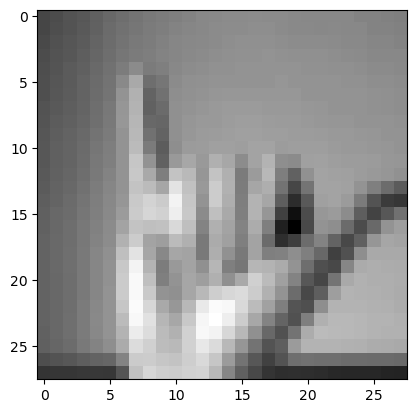

In [22]:
plt.imshow(X[0], cmap='gray'), y[0]

In [23]:
# Defining the CNN

model = keras.models.Sequential()
model.add(keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu', input_shape=(28, 28, 1)))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(64, (5, 5), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(128, (5, 5), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(24, activation='softmax'))

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        832       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        51264     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 128)         204928    
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 3, 3, 128)        0

In [25]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [26]:
save_best_cb = keras.callbacks.ModelCheckpoint('models/initial-end-to-end', save_best_only=True) # Saves the best model so far
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5)

In [27]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), callbacks=[save_best_cb, early_stopping_cb])

Epoch 1/20
782/782 [==============================] - 12s 7ms/step - loss: 0.8814 - accuracy: 0.7288 - val_loss: 0.0909 - val_accuracy: 0.9735
Epoch 2/20
782/782 [==============================] - 5s 6ms/step - loss: 0.0297 - accuracy: 0.9919 - val_loss: 0.0016 - val_accuracy: 1.0000
Epoch 3/20
782/782 [==============================] - 5s 6ms/step - loss: 6.3022e-04 - accuracy: 1.0000 - val_loss: 3.5232e-04 - val_accuracy: 1.0000
Epoch 4/20
782/782 [==============================] - 5s 6ms/step - loss: 2.1372e-04 - accuracy: 1.0000 - val_loss: 1.5817e-04 - val_accuracy: 1.0000
Epoch 5/20
782/782 [==============================] - 5s 6ms/step - loss: 1.0116e-04 - accuracy: 1.0000 - val_loss: 7.2383e-05 - val_accuracy: 1.0000
Epoch 6/20
782/782 [==============================] - 5s 6ms/step - loss: 4.7162e-05 - accuracy: 1.0000 - val_loss: 3.8580e-05 - val_accuracy: 1.0000
Epoch 7/20
782/782 [==============================] - 5s 6ms/step - loss: 2.4253e-05 - accuracy: 1.0000 - val_loss:

In [28]:
history.history

{'loss': [0.8813727498054504,
  0.02968183159828186,
  0.0006302234251052141,
  0.00021371654293034226,
  0.00010116296471096575,
  4.716193143394776e-05,
  2.4253222363768145e-05,
  1.4013256077305414e-05,
  6.833289262431208e-06,
  4.0009986150835175e-06,
  2.374675432292861e-06,
  1.569429741721251e-06,
  9.164813263851102e-07,
  5.731979513257102e-07,
  3.719459016338078e-07,
  2.3527105952325655e-07,
  1.6834218286021496e-07,
  1.0237208414309862e-07,
  6.697175791714471e-08,
  4.452227742035575e-08],
 'accuracy': [0.7287999987602234,
  0.991919994354248,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'val_loss': [0.09090303629636765,
  0.0016238740645349026,
  0.0003523193299770355,
  0.000158167167683132,
  7.238273974508047e-05,
  3.857959382003173e-05,
  1.8519947843742557e-05,
  1.0950555406452622e-05,
  6.608927378692897e-06,
  3.660924448922742e-06,
  2.422826355541474e-06,
  1.5550712078038487

In [29]:
with open('models/intial-end-to-end-history', 'wb') as history_file:
    pickle.dump(history.history, history_file)

In [30]:
h = np.load('models/intial-end-to-end-history', allow_pickle=True)
h

{'loss': [0.8813727498054504,
  0.02968183159828186,
  0.0006302234251052141,
  0.00021371654293034226,
  0.00010116296471096575,
  4.716193143394776e-05,
  2.4253222363768145e-05,
  1.4013256077305414e-05,
  6.833289262431208e-06,
  4.0009986150835175e-06,
  2.374675432292861e-06,
  1.569429741721251e-06,
  9.164813263851102e-07,
  5.731979513257102e-07,
  3.719459016338078e-07,
  2.3527105952325655e-07,
  1.6834218286021496e-07,
  1.0237208414309862e-07,
  6.697175791714471e-08,
  4.452227742035575e-08],
 'accuracy': [0.7287999987602234,
  0.991919994354248,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'val_loss': [0.09090303629636765,
  0.0016238740645349026,
  0.0003523193299770355,
  0.000158167167683132,
  7.238273974508047e-05,
  3.857959382003173e-05,
  1.8519947843742557e-05,
  1.0950555406452622e-05,
  6.608927378692897e-06,
  3.660924448922742e-06,
  2.422826355541474e-06,
  1.5550712078038487

In [31]:
best_model = keras.models.load_model('models/initial-end-to-end')

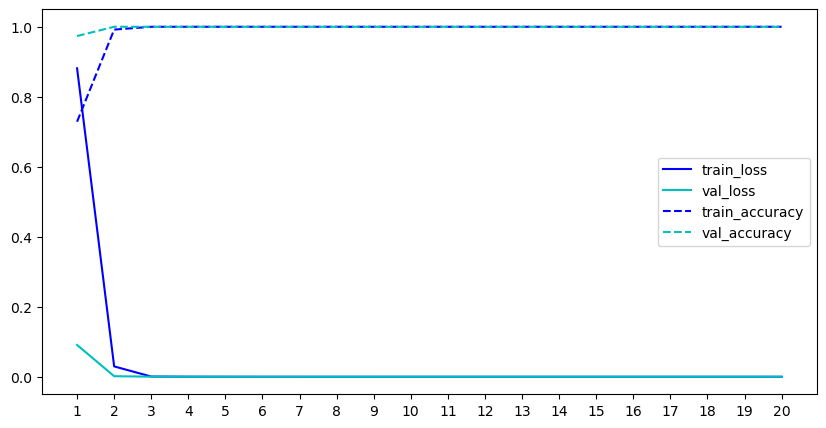

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
n_epochs = len(h['loss'])
ax.plot(range(1, n_epochs+1), h['loss'], color='b', label='train_loss')
ax.plot(range(1, n_epochs+1), h['val_loss'], color='c', label='val_loss')
ax.plot(range(1, n_epochs+1), h['accuracy'], color='b', label='train_accuracy', linestyle='--')
ax.plot(range(1, n_epochs+1), h['val_accuracy'], color='c', label='val_accuracy', linestyle='--')
ax.set_xticks(range(1, n_epochs+1))
ax.legend()

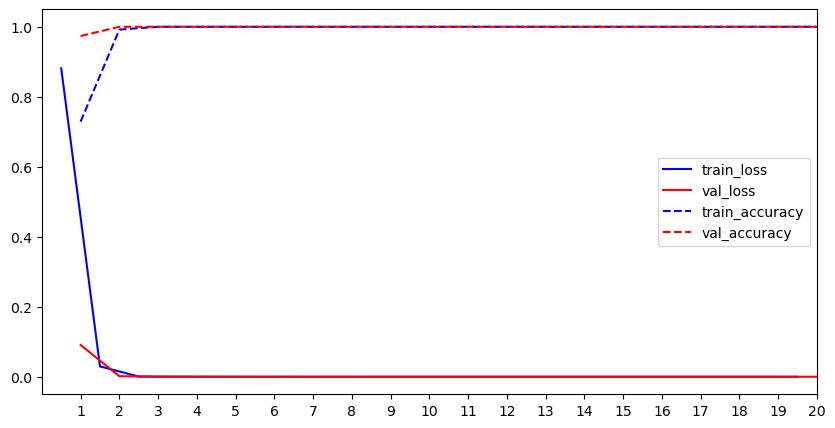

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
n_epochs = len(h['loss'])

# Shift training loss by 0.5 as training loss is measured during the epoch and validation loss is measured after the epoch

x_loss = np.arange(n_epochs+1)-0.5
ax.plot(x_loss[x_loss >= 0], h['loss'], color='b', label='train_loss')
ax.plot(range(1, n_epochs+1), h['val_loss'], color='r', label='val_loss')
ax.plot(range(1, n_epochs+1), h['accuracy'], color='b', label='train_accuracy', linestyle='--')
ax.plot(range(1, n_epochs+1), h['val_accuracy'], color='r', label='val_accuracy', linestyle='--')
ax.set_xlim(0, n_epochs)
ax.set_xticks(range(1, n_epochs+1))
ax.legend()

In [34]:
def get_train_val_plots(h, yticks=None, figsize=(10, 5)):
    # h: Any dictionary like the history.history
    
    fig, ax = plt.subplots(figsize=figsize)
    n_epochs = len(h['loss'])
    x_loss = np.arange(n_epochs+1)-0.5
    
    ax.plot(x_loss[x_loss >= 0], h['loss'], color='b', label='train_loss')
    ax.plot(range(1, n_epochs+1), h['val_loss'], color='r', label='val_loss')
    ax.plot(range(1, n_epochs+1), h['accuracy'], color='b', label='train_accuracy', linestyle='--')
    ax.plot(range(1, n_epochs+1), h['val_accuracy'], color='r', label='val_accuracy', linestyle='--')
    ax.set_xlim(0, n_epochs)
    ax.set_xticks(range(1, n_epochs+1))
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.legend()

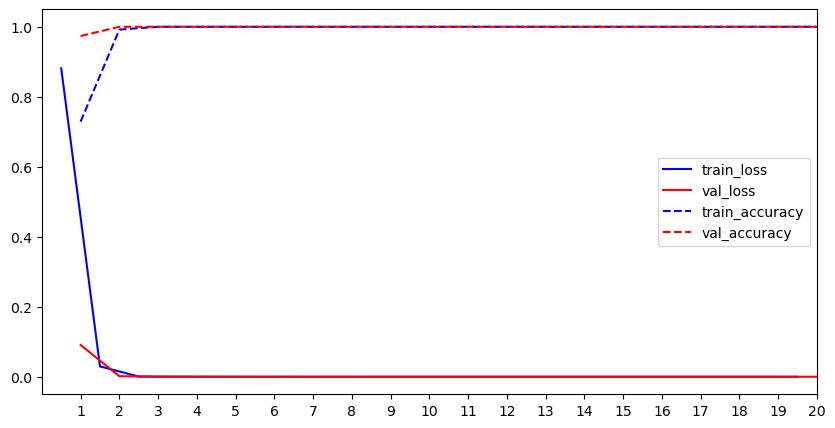

In [35]:
get_train_val_plots(h)

In [36]:
test_df = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv')

In [37]:
X_test, y_test = test_df.drop('label', axis=1), test_df['label']

In [38]:
X_test = tf.reshape(X_test, [-1, 28, 28, 1])

In [39]:
y_test = label_binarizer.transform(y_test)

In [41]:
best_model.evaluate(X_test, y_test)

225/225 [==============================] - 1s 3ms/step - loss: 181.0300 - accuracy: 0.9018


[181.03001403808594, 0.9018405079841614]

In [42]:

def evaluate_model(model, X_test, y_test, label_binarizer):
    X_test_reshape = tf.reshape(X_test, [-1, 28, 28, 1])
    y_test_labels = label_binarizer.transform(y_test)
    results = model.evaluate(X_test_reshape, y_test_labels)
    print(f'Loss: {results[0]:.3f} Accuracy: {results[1]:.3f}')

In [43]:
results = evaluate_model(best_model, test_df.drop('label', axis=1), test_df['label'], label_binarizer)

225/225 [==============================] - 1s 3ms/step - loss: 181.0300 - accuracy: 0.9018
Loss: 181.030 Accuracy: 0.902


In [45]:
test_df = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv')

In [47]:
X_test, y_test = test_df.drop('label', axis=1), test_df['label']

In [48]:
X_test = tf.reshape(X_test, [-1, 28, 28, 1])

In [49]:
d = {chr(ord('a') + i):i for i in range(26)}
d_rev = {i:chr(ord('a') + i) for i in range(26)}
d[' '] = d_rev[' '] = ' '

In [50]:
sentence = 'sign language'

for i in sentence:
    print(d[i], end=' ')

18 8 6 13   11 0 13 6 20 0 6 4 

In [ ]:
best_model.predict(tf.reshape(X_test[0], [-1, 28, 28, 1]))

In [51]:
images_taken = []
result = ''

for i in sentence:
    if i != ' ':
        char_index = np.random.choice(y_test[y_test==ord(i)-ord('a')].index)
        images_taken.append(char_index)
        y_pred = best_model.predict(tf.reshape(X_test[char_index], [-1, 28, 28, 1]))
        result += d_rev[label_binarizer.inverse_transform(y_pred)[0]]
    else:
        result += ' '
print(result)

1/1 [==============================] - 0s 18ms/step
eign langusge


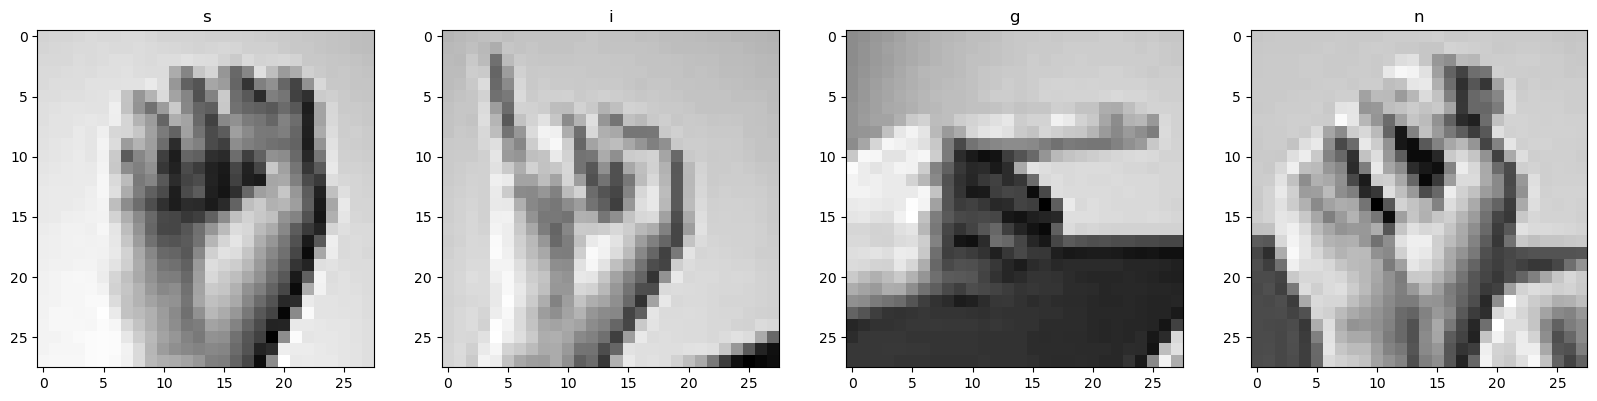

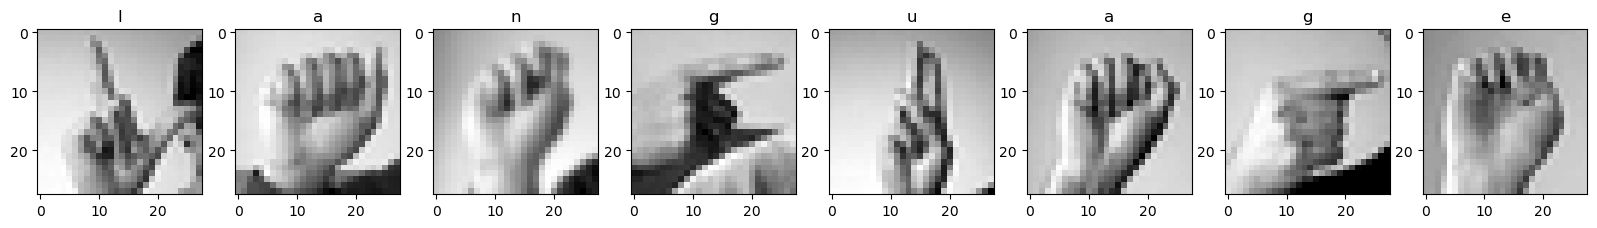

In [52]:
images_taken_dup = list(reversed(images_taken))
for word in sentence.split():
    fig, ax = plt.subplots(1, len(word), figsize=(20, 20))
    for i in range(len(word)):
        ax[i].imshow(X_test[images_taken_dup.pop()], cmap='gray')
        ax[i].set_title(word[i])

In [53]:
def test_on_sentence(model, sentence, X_test, y_test, label_binarizer, figsize=(20, 20)):
    # Random images are taken from X_test along with the corresponding labels in y_test
    # based on the letters in the sentence.
    # These images are fed to the model and its output is printed
    
    sentence = sentence.lower()
    
    d = {chr(ord('a') + i):i for i in range(26)}
    d_rev = {i:chr(ord('a') + i) for i in range(26)}
    d[' '] = d_rev[' '] = ' '
    
    
    images_taken = []
    result = ''
    
    X_test_reshape = tf.reshape(X_test, [-1, 28, 28, 1])
    

    for i in sentence:
        if i != ' ':
            char_index = np.random.choice(y_test[y_test==ord(i)-ord('a')].index)
            images_taken.append(char_index)
            y_pred = model.predict(tf.reshape(X_test_reshape[char_index], [1, 28, 28, 1]))
            result += d_rev[label_binarizer.inverse_transform(y_pred)[0]]
        else:
            result += ' '
            
    print(f'The actual sentence is "{sentence}"')
    print(f'The predicted sentence is "{result}"')
        
    images_taken.reverse()
    for word in sentence.split():
        fig, ax = plt.subplots(1, len(word), figsize=figsize)
        for i in range(len(word)):
            ax[i].imshow(X_test_reshape[images_taken.pop()], cmap='gray')
            ax[i].set_title(word[i])

1/1 [==============================] - 0s 21ms/step
The actual sentence is "sign language"
The predicted sentence is "sign canguage"


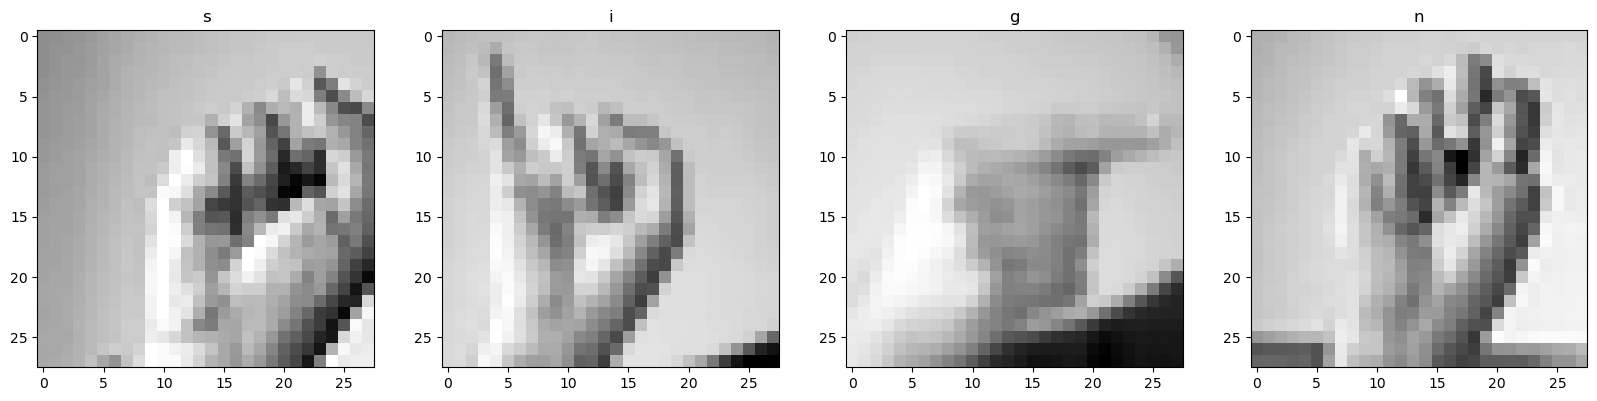

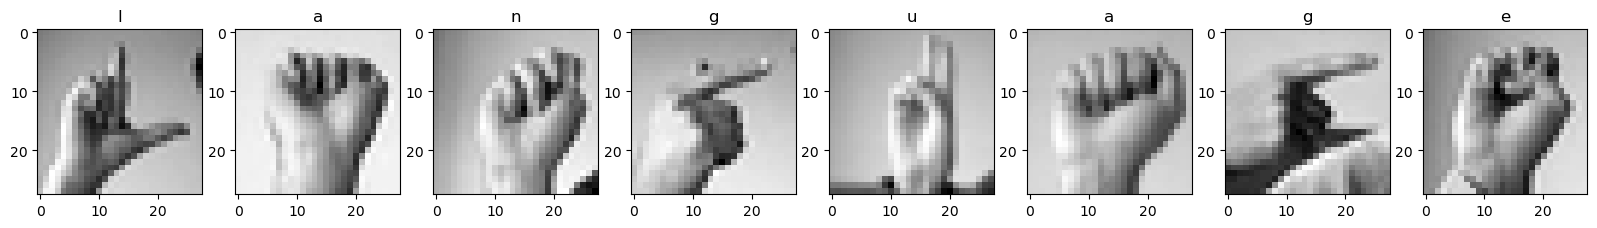

In [54]:
test_on_sentence(best_model, 'sign language', test_df.drop('label', axis=1), test_df['label'], label_binarizer)

In [55]:
# 20% Validation Split

X_train, X_valid = X[:19500], X[19500:]
y_train, y_valid = y[:19500], y[19500:]

In [56]:
n_pairs = 3
models_pairs = [keras.models.Sequential() for i in range(n_pairs)]
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5)

for n in range(1, n_pairs+1):
    models_pairs[n-1].add(keras.layers.Conv2D(32, (5, 5), padding='same', activation='relu', input_shape=(28, 28, 1)))
    models_pairs[n-1].add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    for i in range(1, n):
        models_pairs[n-1].add(keras.layers.Conv2D(32*(i+1), (5, 5), padding='same', activation='relu'))
        models_pairs[n-1].add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    models_pairs[n-1].add(keras.layers.Flatten())
    models_pairs[n-1].add(keras.layers.Dense(128, activation='relu'))
    models_pairs[n-1].add(keras.layers.Dense(24, activation='softmax'))
    models_pairs[n-1].compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    save_best_cb = keras.callbacks.ModelCheckpoint(f'models/experiment-1-{n}', save_best_only=True)
    history = models_pairs[n-1].fit(X_train, y_train, epochs=15, validation_data=(X_valid, y_valid), callbacks=[save_best_cb, early_stopping_cb])
    with open(f'models/experiment-1-{n}-history', 'wb') as history_file:
        pickle.dump(history.history, history_file)

Epoch 1/15
610/610 [==============================] - 5s 7ms/step - loss: 1.2679 - accuracy: 0.6499 - val_loss: 0.3988 - val_accuracy: 0.8885
Epoch 2/15
610/610 [==============================] - 3s 6ms/step - loss: 0.1759 - accuracy: 0.9639 - val_loss: 0.1055 - val_accuracy: 0.9761
Epoch 3/15
610/610 [==============================] - 4s 6ms/step - loss: 0.0426 - accuracy: 0.9972 - val_loss: 0.0228 - val_accuracy: 1.0000
Epoch 4/15
610/610 [==============================] - 3s 6ms/step - loss: 0.0140 - accuracy: 0.9998 - val_loss: 0.0098 - val_accuracy: 1.0000
Epoch 5/15
610/610 [==============================] - 3s 5ms/step - loss: 0.0064 - accuracy: 1.0000 - val_loss: 0.0045 - val_accuracy: 1.0000
Epoch 6/15
610/610 [==============================] - 3s 5ms/step - loss: 0.0034 - accuracy: 1.0000 - val_loss: 0.0032 - val_accuracy: 1.0000
Epoch 7/15
610/610 [==============================] - 4s 6ms/step - loss: 0.0020 - accuracy: 1.0000 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 

In [57]:
models_pairs[0].summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        832       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 6272)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               802944    
                                                                 
 dense_3 (Dense)             (None, 24)                3096      
                                                                 
Total params: 806,872
Trainable params: 806,872
Non-trainable params: 0
________________________________________________

In [58]:
models_pairs[1].summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 28, 28, 32)        832       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 14, 14, 64)        51264     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 3136)              0         
                                                                 
 dense_4 (Dense)             (None, 128)              

In [59]:
models_pairs[2].summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 28, 28, 32)        832       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 14, 14, 64)        51264     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 7, 7, 96)          153696    
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 3, 3, 96)        

In [60]:
for index in range(n_pairs):
    model = keras.models.load_model(f'models/experiment-1-{index+1}')
    model.evaluate(X_valid, y_valid)

249/249 [==============================] - 1s 3ms/step - loss: 1.9966e-06 - accuracy: 1.0000


In [61]:
h_1_1 = np.load('models/experiment-1-1-history', allow_pickle=True)
h_1_2 = np.load('models/experiment-1-2-history', allow_pickle=True)
h_1_3 = np.load('models/experiment-1-3-history', allow_pickle=True)

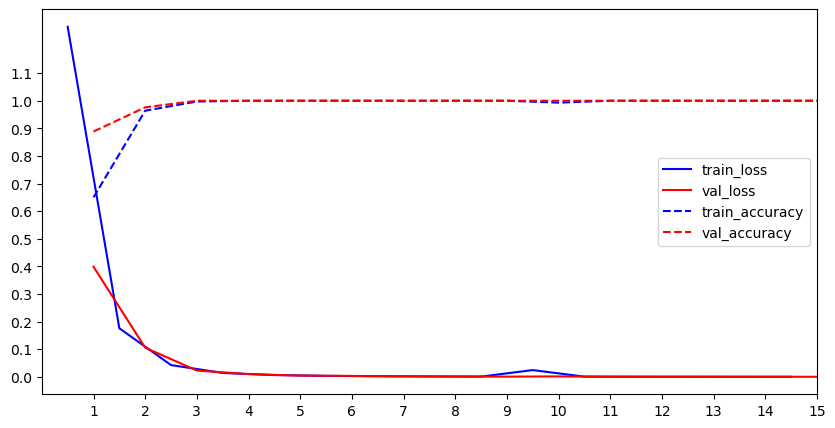

In [62]:
get_train_val_plots(h_1_1, yticks=np.arange(0, 1.2, 0.1))

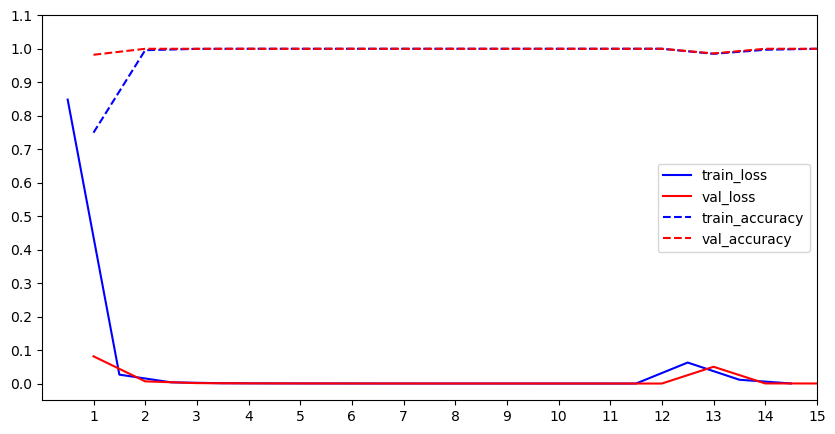

In [63]:
get_train_val_plots(h_1_2, yticks=np.arange(0, 1.2, 0.1))

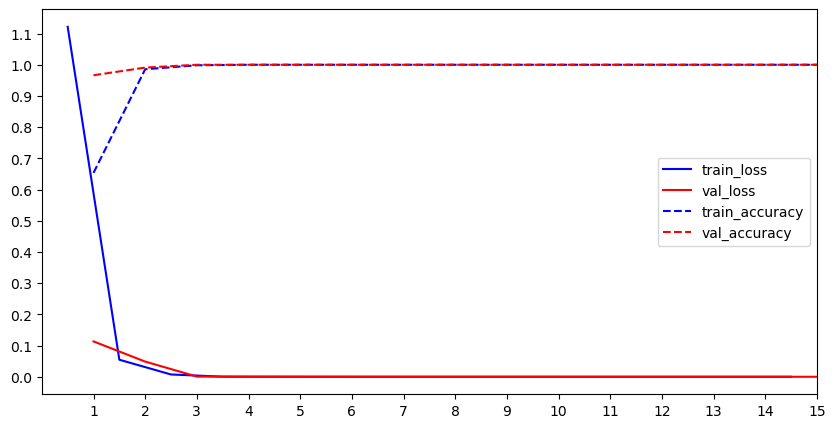

In [64]:

get_train_val_plots(h_1_3, yticks=np.arange(0, 1.2, 0.1))

In [65]:
n_tests = 3

models = []
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5)


for i in range(n_tests):
    model = keras.models.Sequential()
    models.append(model)
    model.add(keras.layers.Input(shape=(28, 28, 1)))
    for pairs in range(3):
        model.add(keras.layers.Conv2D((8*(i+1))*(2**pairs), (5, 5), padding='same', activation='relu'))
        model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(128, activation='relu'))
    model.add(keras.layers.Dense(24, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    save_best_cb = keras.callbacks.ModelCheckpoint(f'models/experiment-fmaps-{i+1}', save_best_only=True)
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid), callbacks=[save_best_cb, early_stopping_cb])
    with open(f'models/experiment-fmaps-{i+1}-history', 'wb') as history_file:
        pickle.dump(history.history, history_file)

Epoch 1/10
610/610 [==============================] - 6s 7ms/step - loss: 1.1478 - accuracy: 0.6465 - val_loss: 0.1927 - val_accuracy: 0.9488
Epoch 2/10
610/610 [==============================] - 4s 7ms/step - loss: 0.1079 - accuracy: 0.9708 - val_loss: 0.0570 - val_accuracy: 0.9854
Epoch 3/10
610/610 [==============================] - 5s 7ms/step - loss: 0.0131 - accuracy: 0.9987 - val_loss: 0.0074 - val_accuracy: 0.9990
Epoch 4/10
610/610 [==============================] - 4s 7ms/step - loss: 0.0023 - accuracy: 1.0000 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 5/10
610/610 [==============================] - 5s 8ms/step - loss: 0.0010 - accuracy: 1.0000 - val_loss: 7.4375e-04 - val_accuracy: 1.0000
Epoch 6/10
610/610 [==============================] - 4s 7ms/step - loss: 5.6334e-04 - accuracy: 1.0000 - val_loss: 5.0193e-04 - val_accuracy: 1.0000
Epoch 7/10
610/610 [==============================] - 3s 5ms/step - loss: 0.0634 - accuracy: 0.9802 - val_loss: 0.0089 - val_accuracy: 0

In [69]:
models[0].summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 28, 28, 8)         208       
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 14, 14, 8)        0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 14, 14, 16)        3216      
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 7, 7, 16)         0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 7, 7, 32)          12832     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 3, 3, 32)        

In [70]:
models[1].summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 28, 28, 16)        416       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 14, 14, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 14, 14, 32)        12832     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 7, 7, 32)         0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (None, 7, 7, 64)          51264     
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 3, 3, 64)        

In [71]:
for index in range(n_tests):
    model = keras.models.load_model(f'models/experiment-fmaps-{index+1}')
    model.evaluate(X_valid, y_valid)

249/249 [==============================] - 1s 3ms/step - loss: 3.8371e-05 - accuracy: 1.0000


In [73]:
h_2_1 = np.load('models/experiment-fmaps-1-history', allow_pickle=True)
h_2_2 = np.load('models/experiment-fmaps-2-history', allow_pickle=True)
h_2_3 = np.load('models/experiment-fmaps-3-history', allow_pickle=True)

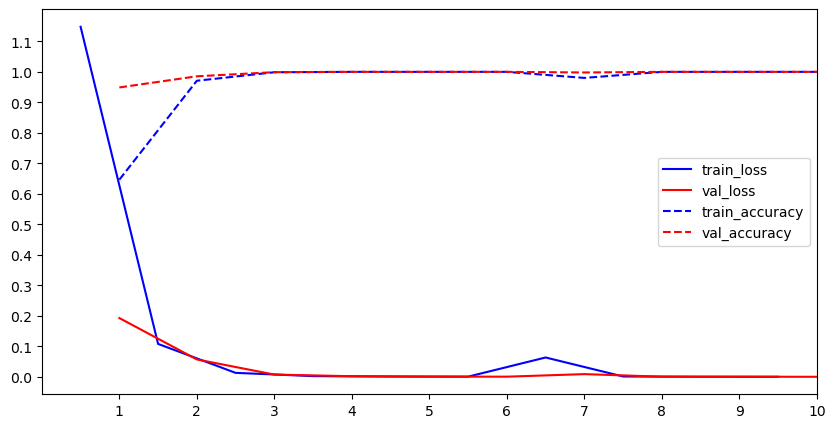

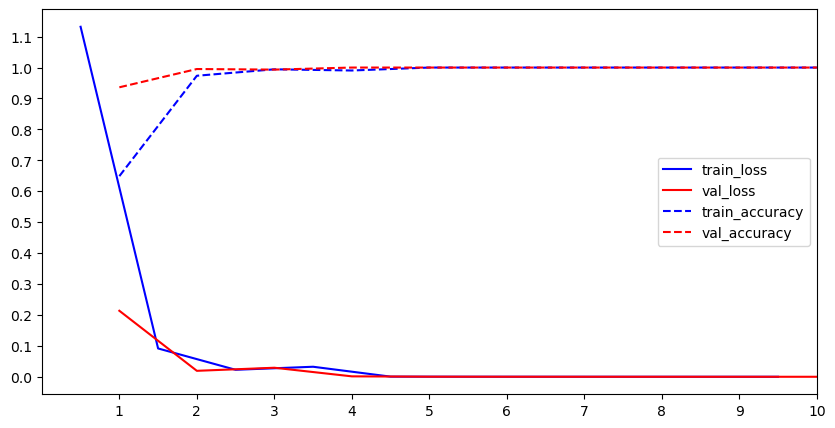

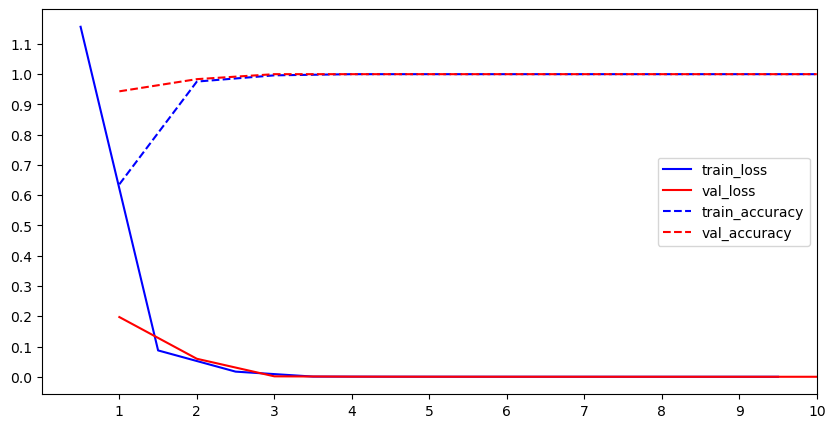

In [74]:
get_train_val_plots(h_2_1, yticks=np.arange(0, 1.2, 0.1))
get_train_val_plots(h_2_2, yticks=np.arange(0, 1.2, 0.1))
get_train_val_plots(h_2_3, yticks=np.arange(0, 1.2, 0.1))

In [76]:

save_best_cb = keras.callbacks.ModelCheckpoint(f'models/experiment-fiters-1', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5)

model = keras.models.Sequential()
model.add(keras.layers.Conv2D(24, (3, 3), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(48, (3, 3), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Conv2D(96, (3, 3), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(24, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid), callbacks=[save_best_cb, early_stopping_cb])
with open(f'models/experiment-filters-1-history', 'wb') as history_file:
    pickle.dump(history.history, history_file)

Epoch 1/10
610/610 [==============================] - 6s 8ms/step - loss: 1.0689 - accuracy: 0.6745 - val_loss: 0.2402 - val_accuracy: 0.9188
Epoch 2/10
610/610 [==============================] - 4s 7ms/step - loss: 0.0777 - accuracy: 0.9784 - val_loss: 0.0372 - val_accuracy: 0.9915
Epoch 3/10
610/610 [==============================] - 4s 7ms/step - loss: 0.0081 - accuracy: 0.9993 - val_loss: 0.0028 - val_accuracy: 0.9999
Epoch 4/10
610/610 [==============================] - 3s 5ms/step - loss: 0.0027 - accuracy: 0.9996 - val_loss: 0.0555 - val_accuracy: 0.9858
Epoch 5/10
610/610 [==============================] - 5s 8ms/step - loss: 0.0376 - accuracy: 0.9885 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 6/10
610/610 [==============================] - 4s 7ms/step - loss: 4.9542e-04 - accuracy: 1.0000 - val_loss: 7.2001e-04 - val_accuracy: 1.0000
Epoch 7/10
610/610 [==============================] - 4s 7ms/step - loss: 2.4184e-04 - accuracy: 1.0000 - val_loss: 2.8771e-04 - val_accurac

In [77]:
model = keras.models.load_model('models/experiment-fiters-1/')
model.evaluate(X_valid, y_valid)

249/249 [==============================] - 1s 3ms/step - loss: 1.3010e-04 - accuracy: 1.0000


[0.00013010174734517932, 1.0]

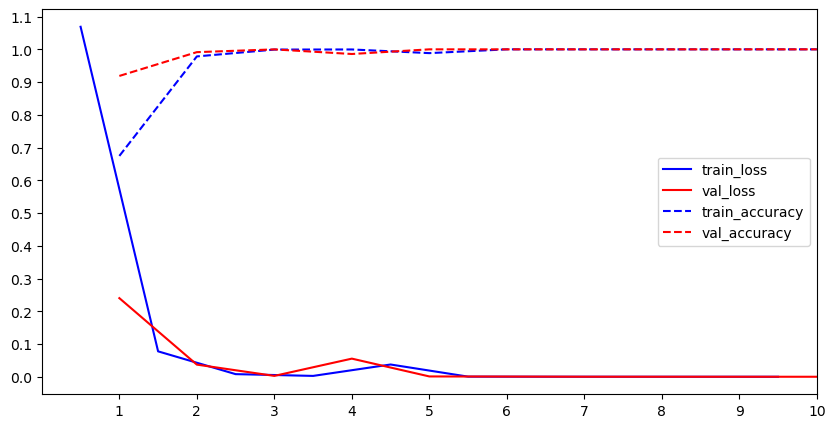

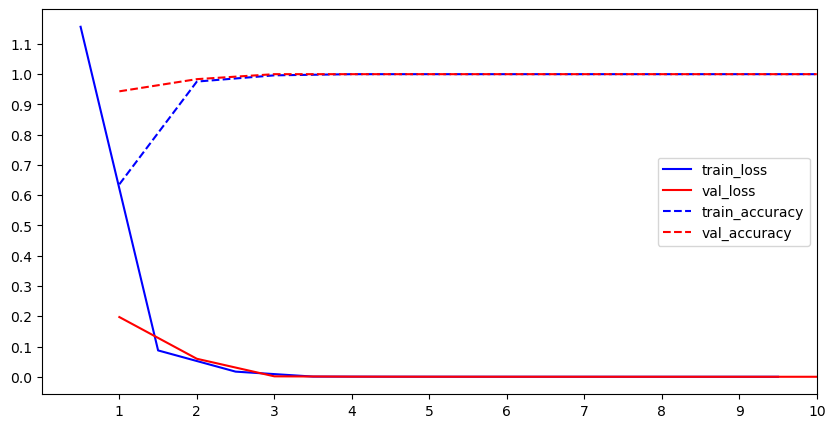

In [79]:
h_2_3 = np.load('models/experiment-fmaps-3-history', allow_pickle=True)
h = np.load('models/experiment-filters-1-history', allow_pickle=True)
get_train_val_plots(h, yticks=np.arange(0, 1.2, 0.1))
get_train_val_plots(h_2_3, yticks=np.arange(0, 1.2, 0.1))

In [80]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5)

dropout_rates = [0.3, 0.4, 0.5]

for index, i in enumerate(dropout_rates):
    model = keras.models.Sequential()
    model.add(keras.layers.Conv2D(24, (5, 5), padding='same', activation='relu'))
    model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(keras.layers.Dropout(i))
    model.add(keras.layers.Conv2D(48, (5, 5), padding='same', activation='relu'))
    model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(keras.layers.Dropout(i))
    model.add(keras.layers.Conv2D(96, (5, 5), padding='same', activation='relu'))
    model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(keras.layers.Dropout(i))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(128, activation='relu'))
    model.add(keras.layers.Dropout(i))
    model.add(keras.layers.Dense(24, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    save_best_cb = keras.callbacks.ModelCheckpoint(f'models/experiment-dropout-{index}', save_best_only=True)
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid), callbacks=[save_best_cb, early_stopping_cb])
    with open(f'models/experiment-dropout-{index}-history', 'wb') as history_file:
        pickle.dump(history.history, history_file)

Epoch 1/10


2023-03-17 07:37:07.425663: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_9/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


610/610 [==============================] - 7s 9ms/step - loss: 1.7636 - accuracy: 0.4453 - val_loss: 0.3071 - val_accuracy: 0.9004
Epoch 2/10
610/610 [==============================] - 5s 8ms/step - loss: 0.3249 - accuracy: 0.8882 - val_loss: 0.0265 - val_accuracy: 0.9971
Epoch 3/10
610/610 [==============================] - 5s 8ms/step - loss: 0.1425 - accuracy: 0.9507 - val_loss: 0.0093 - val_accuracy: 0.9979
Epoch 4/10
610/610 [==============================] - 5s 8ms/step - loss: 0.0882 - accuracy: 0.9702 - val_loss: 0.0031 - val_accuracy: 0.9999
Epoch 5/10
610/610 [==============================] - 5s 8ms/step - loss: 0.0684 - accuracy: 0.9774 - val_loss: 0.0019 - val_accuracy: 0.9999
Epoch 6/10
610/610 [==============================] - 6s 9ms/step - loss: 0.0529 - accuracy: 0.9821 - val_loss: 5.0912e-04 - val_accuracy: 1.0000
Epoch 7/10
610/610 [==============================] - 4s 6ms/step - loss: 0.0485 - accuracy: 0.9845 - val_loss: 5.7804e-04 - val_accuracy: 1.0000
Epoch 8/1

2023-03-17 07:37:58.467289: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_10/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


610/610 [==============================] - 7s 9ms/step - loss: 2.1988 - accuracy: 0.3124 - val_loss: 0.5140 - val_accuracy: 0.8478
Epoch 2/10
610/610 [==============================] - 6s 9ms/step - loss: 0.5911 - accuracy: 0.7990 - val_loss: 0.0934 - val_accuracy: 0.9832
Epoch 3/10
610/610 [==============================] - 5s 9ms/step - loss: 0.3036 - accuracy: 0.8946 - val_loss: 0.0389 - val_accuracy: 0.9927
Epoch 4/10
610/610 [==============================] - 5s 8ms/step - loss: 0.1914 - accuracy: 0.9355 - val_loss: 0.0095 - val_accuracy: 0.9996
Epoch 5/10
610/610 [==============================] - 5s 8ms/step - loss: 0.1491 - accuracy: 0.9491 - val_loss: 0.0047 - val_accuracy: 1.0000
Epoch 6/10
610/610 [==============================] - 5s 8ms/step - loss: 0.1218 - accuracy: 0.9604 - val_loss: 0.0026 - val_accuracy: 1.0000
Epoch 7/10
610/610 [==============================] - 5s 8ms/step - loss: 0.1116 - accuracy: 0.9642 - val_loss: 0.0013 - val_accuracy: 1.0000
Epoch 8/10
610/61

2023-03-17 07:39:21.453552: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_11/dropout_8/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


610/610 [==============================] - 7s 8ms/step - loss: 2.7734 - accuracy: 0.1481 - val_loss: 1.3979 - val_accuracy: 0.6513
Epoch 2/10
610/610 [==============================] - 5s 8ms/step - loss: 1.2970 - accuracy: 0.5579 - val_loss: 0.4805 - val_accuracy: 0.8874
Epoch 3/10
610/610 [==============================] - 5s 8ms/step - loss: 0.8042 - accuracy: 0.7205 - val_loss: 0.2566 - val_accuracy: 0.9490
Epoch 4/10
610/610 [==============================] - 6s 9ms/step - loss: 0.5882 - accuracy: 0.7953 - val_loss: 0.1713 - val_accuracy: 0.9654
Epoch 5/10
610/610 [==============================] - 5s 8ms/step - loss: 0.4696 - accuracy: 0.8362 - val_loss: 0.1087 - val_accuracy: 0.9842
Epoch 6/10
610/610 [==============================] - 5s 8ms/step - loss: 0.3840 - accuracy: 0.8665 - val_loss: 0.0596 - val_accuracy: 0.9921
Epoch 7/10
610/610 [==============================] - 5s 8ms/step - loss: 0.3362 - accuracy: 0.8859 - val_loss: 0.0381 - val_accuracy: 0.9979
Epoch 8/10
610/61

In [86]:
for index in range(3):
    model = keras.models.load_model(f'models/experiment-dropout-{index}')
    model.evaluate(X_valid, y_valid)

249/249 [==============================] - 1s 3ms/step - loss: 0.0113 - accuracy: 0.9996


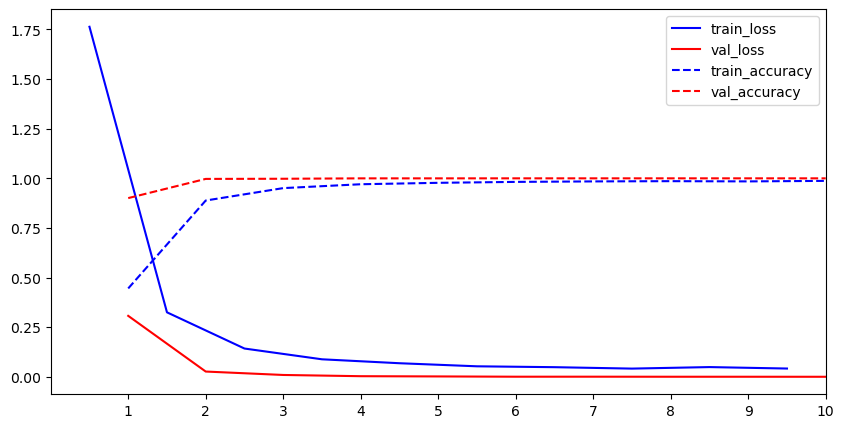

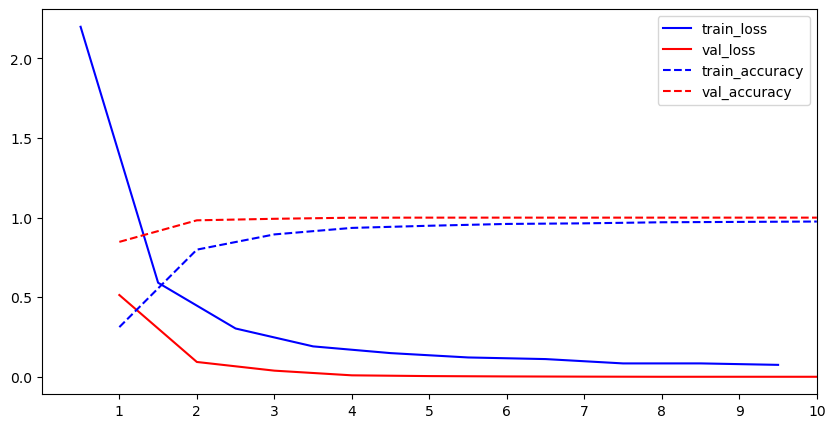

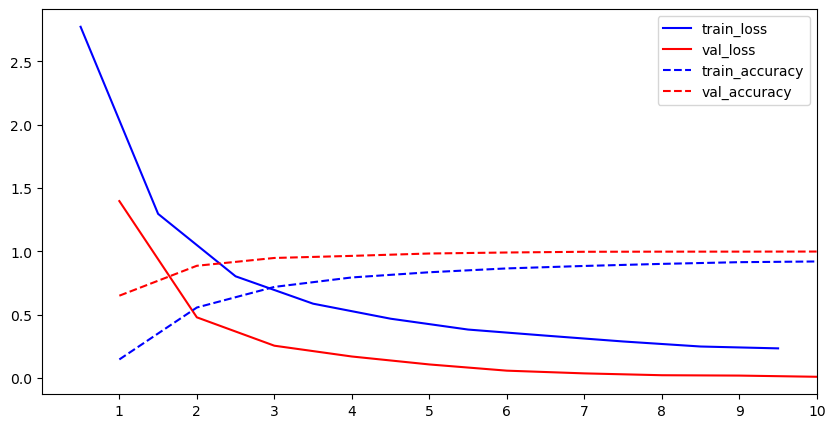

In [88]:
h_0 = np.load('models/experiment-dropout-0-history', allow_pickle=True)
h_1 = np.load('models/experiment-dropout-1-history', allow_pickle=True)
h_2 = np.load('models/experiment-dropout-2-history', allow_pickle=True)

get_train_val_plots(h_0)
get_train_val_plots(h_1)
get_train_val_plots(h_2)

In [90]:
data_augmentation = keras.models.Sequential()
data_augmentation.add(keras.layers.RandomRotation(0.1, fill_mode='nearest', input_shape=(28, 28, 1)))
data_augmentation.add(keras.layers.RandomZoom((0.15, 0.2), fill_mode='nearest'))
data_augmentation.add(keras.layers.RandomTranslation(0.1, 0.1, fill_mode='nearest'))

model = keras.models.Sequential()

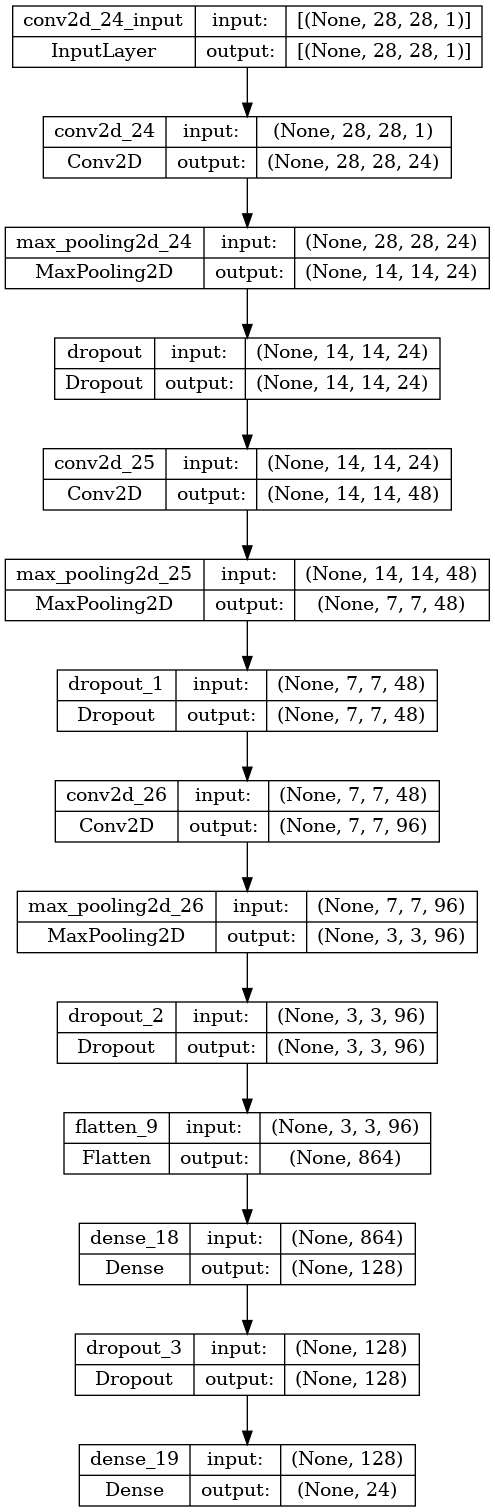

In [92]:
best_model = keras.models.load_model('models/experiment-dropout-0/')
plot_model(best_model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [94]:
test_df = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv')
X_test, y_test = test_df.drop('label', axis=1), test_df['label']

In [96]:
best_model = keras.models.load_model('models/experiment-dropout-0/')

In [98]:
evaluate_model(best_model, X_test, y_test, label_binarizer)

225/225 [==============================] - 1s 3ms/step - loss: 19.0935 - accuracy: 0.9717
Loss: 19.094 Accuracy: 0.972


In [100]:
test_df = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv')
X_test, y_test = test_df.drop('label', axis=1), test_df['label']

In [101]:
# Applying normalisation which is applied for X_train
X_test /= 255.0

In [102]:
best_model = keras.models.load_model('models/experiment-dropout-0/')

In [103]:
evaluate_model(best_model, X_test, y_test, label_binarizer)

225/225 [==============================] - 1s 3ms/step - loss: 0.0759 - accuracy: 0.9792
Loss: 0.076 Accuracy: 0.979


TRANSFORMER BASED APPROACH****

In [104]:

import torch
import torch.nn.functional as F
import torch.nn as nn

#num_landmark = 543
max_length = 80
num_class  = 250
num_point  = 82  # LIP, LHAND, RHAND

def pack_seq(
    seq,
):
    length = [len(s) for s in seq]
    batch_size = len(seq)
    num_landmark=seq[0].shape[1]

    x = torch.zeros((batch_size, max(length), num_landmark, 3)).to(seq[0].device)
    x_mask = torch.zeros((batch_size, max(length))).to(seq[0].device)
    for b in range(batch_size):
        L = length[b]
        x[b, :L] = seq[b][:L]
        x_mask[b, L:] = 1
    x_mask = (x_mask>0.5)
    x = x.reshape(batch_size,-1,num_landmark*3)
    return x, x_mask


class FeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, embed_dim),
        )
    def forward(self, x):
        return self.mlp(x)


#https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html
class MultiHeadAttention(nn.Module):
    def __init__(self,
            embed_dim,
            num_head,
            batch_first,
        ):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim,
            num_heads=num_head,
            bias=True,
            add_bias_kv=False,
            kdim=None,
            vdim=None,
            dropout=0.0,
            batch_first=batch_first,
        )

    def forward(self, x, x_mask):
        out, _ = self.mha(x,x,x, key_padding_mask=x_mask)
        return out


def positional_encoding(length, embed_dim):
    dim = embed_dim//2

    position = np.arange(length)[:, np.newaxis]     # (seq, 1)
    dim = np.arange(dim)[np.newaxis, :]/dim   # (1, dim)

    angle = 1 / (10000**dim)         # (1, dim)
    angle = position * angle    # (pos, dim)

    pos_embed = np.concatenate(
        [np.sin(angle), np.cos(angle)],
        axis=-1
    )
    pos_embed = torch.from_numpy(pos_embed).float()
    return pos_embed

class TransformerBlock(nn.Module):
    def __init__(self,
        embed_dim,
        num_head,
        out_dim,
        batch_first=True,
    ):
        super().__init__()
        self.attn  = MultiHeadAttention(embed_dim, num_head,batch_first)
        self.ffn   = FeedForward(embed_dim, out_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(out_dim)

    def forward(self, x, x_mask=None):
        x = x + self.attn((self.norm1(x)), x_mask)
        x = x + self.ffn((self.norm2(x)))
        return x

class Net(nn.Module):

    def __init__(self, num_class=num_class):
        super().__init__()
        self.output_type = ['inference', 'loss']

        num_block = 1
        embed_dim = 1024
        num_head  = 8

        pos_embed = positional_encoding(max_length, embed_dim)
        # self.register_buffer('pos_embed', pos_embed)
        self.pos_embed = nn.Parameter(pos_embed)

        self.cls_embed = nn.Parameter(torch.zeros((1, embed_dim)))
        self.x_embed = nn.Sequential(
            nn.Linear(num_point * 3, embed_dim, bias=False),
        )

        self.encoder = nn.ModuleList([
            TransformerBlock(
                embed_dim,
                num_head,
                embed_dim,
            ) for i in range(num_block)
        ])
        self.logit = nn.Linear(embed_dim, num_class)

    def forward(self, batch):
        length = [len(x) for x in batch['xyz']]
        xyz = batch['xyz']

        x, x_mask = pack_seq(xyz)
        B,L,_ = x.shape
        x = self.x_embed(x)
        x = x + self.pos_embed[:L].unsqueeze(0)

        x = torch.cat([
            self.cls_embed.unsqueeze(0).repeat(B,1,1),
            x
        ],1)
        x_mask = torch.cat([
            torch.zeros(B,1).to(x_mask),
            x_mask
        ],1)


        #x = F.dropout(x,p=0.25,training=self.training)
        for block in self.encoder:
            x = block(x,x_mask)

        cls = x[:,0]
        cls = F.dropout(cls,p=0.4,training=self.training)
        logit = self.logit(cls)

        output = {}
        if 'loss' in self.output_type:
            output['label_loss'] = F.cross_entropy(logit, batch['label'])

        if 'inference' in self.output_type:
            output['sign'] = torch.softmax(logit,-1)

        return output


def pre_process(xyz):
    xyz = xyz - xyz[~torch.isnan(xyz)].mean(0,keepdims=True) #noramlisation to common mean
    xyz = xyz / xyz[~torch.isnan(xyz)].std(0, keepdims=True)
    
    lip = xyz[:, LIP]
    lhand = xyz[:, LHAND]
    rhand = xyz[:, RHAND]
    xyz = torch.cat([ #(none, 82, 3)
        lip,
        lhand,
        rhand,
    ],1)
    xyz[torch.isnan(xyz)] = 0
    xyz = xyz[:max_length]
    return xyz

CONVERTING INTO TF LITE****

In [105]:

#simplfiy for one video input 
max_length = 96  #reduce this if gets out of memory error

class InputNet(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.max_length = max_length 
  
    def forward(self, xyz):
        xyz = xyz - xyz[~torch.isnan(xyz)].mean(0,keepdim=True) #noramlisation to common maen
        xyz = xyz / xyz[~torch.isnan(xyz)].std(0, keepdim=True)

        LIP = [
            61, 185, 40, 39, 37, 0, 267, 269, 270, 409,
            291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
            78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
            95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
        ]
        #LHAND = np.arange(468, 489).tolist()
        #RHAND = np.arange(522, 543).tolist()

        lip = xyz[:, LIP]
        lhand = xyz[:, 468:489]
        rhand = xyz[:, 522:543]
        xyz = torch.cat([  # (none, 82, 3)
            lip,
            lhand,
            rhand,
        ], 1)
        xyz[torch.isnan(xyz)] = 0
        x = xyz[:self.max_length]
        return x


#overwrite the model used in training ....

# use fix dimension
class MultiHeadAttention(nn.Module):
    def __init__(self,
            embed_dim,
            num_head,
            batch_first,
        ):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim,
            num_heads=num_head,
            bias=True,
            add_bias_kv=False,
            kdim=None,
            vdim=None,
            dropout=0.0,
            batch_first=batch_first,
        )
    #https://github.com/pytorch/text/blob/60907bf3394a97eb45056a237ca0d647a6e03216/torchtext/modules/multiheadattention.py#L5
    def forward(self, x):
        # out,_ = self.mha(x,x,x,need_weights=False)
        # out,_ = F.multi_head_attention_forward(
        #     x, x, x,
        #     self.mha.embed_dim,
        #     self.mha.num_heads,
        #     self.mha.in_proj_weight,
        #     self.mha.in_proj_bias,
        #     self.mha.bias_k,
        #     self.mha.bias_v,
        #     self.mha.add_zero_attn,
        #     0,#self.mha.dropout,
        #     self.mha.out_proj.weight,
        #     self.mha.out_proj.bias,
        #     training=False,
        #     key_padding_mask=None,
        #     need_weights=False,
        #     attn_mask=None,
        #     average_attn_weights=False
        # )
 
        #qkv = F.linear(x, self.mha.in_proj_weight, self.mha.in_proj_bias)
        #qkv = qkv.reshape(-1,3,1024)
        #q,k,v = qkv[[0],0], qkv[:,1],  qkv[:,2]

        q = F.linear(x[:1], self.mha.in_proj_weight[:1024], self.mha.in_proj_bias[:1024]) #since we need only cls
        k = F.linear(x, self.mha.in_proj_weight[1024:2048], self.mha.in_proj_bias[1024:2048])
        v = F.linear(x, self.mha.in_proj_weight[2048:], self.mha.in_proj_bias[2048:]) 
        q = q.reshape(-1, 8, 128).permute(1, 0, 2)
        k = k.reshape(-1, 8, 128).permute(1, 2, 0)
        v = v.reshape(-1, 8, 128).permute(1, 0, 2)
        dot  = torch.matmul(q, k) * (1/128**0.5) # H L L
        attn = F.softmax(dot, -1)  #   L L
        out  = torch.matmul(attn, v)  #   L H dim
        out  = out.permute(1, 0, 2).reshape(-1, 1024)
        out  = F.linear(out, self.mha.out_proj.weight, self.mha.out_proj.bias)  
        return out

# remove mask
class TransformerBlock(nn.Module):
    def __init__(self,
        embed_dim,
        num_head,
        out_dim,
        batch_first=True,
    ):
        super().__init__()
        self.attn  = MultiHeadAttention(embed_dim, num_head,batch_first)
        self.ffn   = FeedForward(embed_dim, out_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(out_dim)

    def forward(self, x): 
        x = x[:1] + self.attn((self.norm1(x)))
        x = x + self.ffn((self.norm2(x)))
        return x

class SingleNet(nn.Module):

    def __init__(self, num_class=num_class):
        super().__init__()
        self.num_block = 1
        self.embed_dim = 1024
        self.num_head  = 8
        self.max_length = max_length
        self.num_point = num_point

        pos_embed = positional_encoding(max_length, self.embed_dim)
        self.pos_embed = nn.Parameter(pos_embed)

        self.cls_embed = nn.Parameter(torch.zeros((1, self.embed_dim)))
        self.x_embed = nn.Sequential(
            nn.Linear(num_point * 3, self.embed_dim, bias=False),
        )

        self.encoder = nn.ModuleList([
            TransformerBlock(
                self.embed_dim,
                self.num_head,
                self.embed_dim,
                batch_first=False
            ) for i in range(self.num_block)
        ])
        self.logit = nn.Linear(self.embed_dim, num_class)

    def forward(self, xyz):
        L = xyz.shape[0]
        x_embed = self.x_embed(xyz.flatten(1)) 
        x = x_embed[:L] + self.pos_embed[:L]
        x = torch.cat([
            self.cls_embed,
            x
        ],0)
        #x = x.unsqueeze(1)

        #for block in self.encoder: x = block(x) #remove tflite loop
        x = self.encoder[0](x)
        cls = x[[0]]
        logit = self.logit(cls)
        return logit
    

In [106]:
#pytorch to onnx to tflite
if 0:
    
    name='transformer-pool-2b' 
    input_onnx_file   = f'{fold_dir}/{name}.input.onnx'
    single_onnx_file  = f'{fold_dir}/{name}.single.onnx' 
    input_tf_file    = f'{fold_dir}/input_tf'
    single_tf_file   = f'{fold_dir}/single_tf'
    tf_file     = f'{fold_dir}/tf'
    tflite_file = f'{fold_dir}/{name}-{max_length}.tflite'

    def run_convert_onnx(): 
        if 1:
            torch.onnx.export(
                input_net,
                #torch.jit.script(input_net),
                #torch.jit.trace(input_net, torch.zeros(100,num_landmark,3)),          # model being run 
                torch.zeros((100,num_landmark,3)), # model input (or a tuple for multiple inputs)
                input_onnx_file,             # where to save the model (can be a file or file-like object)
                export_params = True,        # store the trained parameter weights inside the model file
                opset_version = 12,          # the ONNX version to export the model to
                do_constant_folding=True,    # whether to execute constant folding for optimization 
                input_names =  ['inputs'],    # the model's input names
                output_names = ['outputs'],   # the model's output names
                dynamic_axes={
                    'inputs': {0: 'length'},
                    #'output': {0: 'length'},
                },
                #verbose = True,
            )
            torch.onnx.export(
                single_net,         
                #torch.jit.script(single_net),
                #torch.jit.trace(single_net, torch.zeros(max_length,82,3)),           

                torch.zeros((max_length,82,3)), 
                single_onnx_file,             
                export_params = True,         
                opset_version = 12, 
                do_constant_folding=True,      
                input_names =  ['inputs'],     
                output_names = ['outputs'],  
                dynamic_axes={
                    'inputs': {0: 'length'},
                },
                #verbose = True,
            )
            print('torch.onnx.export() passed !!')

        if 1:
            for f in [input_onnx_file, single_onnx_file]:
                if f is None: continue
                model = onnx.load(f)
                onnx.checker.check_model(model)
                model_simple, check = onnxsim.simplify(model)
                onnx.save(model_simple, f)
            print('onnx simplify() passed !!')


    def run_convert_tflite():
        if 1:
            tf_rep = prepare(onnx.load(input_onnx_file))
            tf_rep.export_graph(input_tf_file) 
            tf_rep = prepare(onnx.load(single_onnx_file))
            tf_rep.export_graph(single_tf_file) 
            print('tf_rep.export_graph() passed !!')

        if 1:
            class TFModel(tf.Module):
                def __init__(self):
                    super(TFModel, self).__init__()
                    self.input  = tf.saved_model.load(input_tf_file)
                    self.single = tf.saved_model.load(single_tf_file)
                    self.input.trainable = False
                    self.single.trainable = False

                @tf.function(input_signature=[
                    tf.TensorSpec(shape=[None, 543, 3], dtype=tf.float32, name='inputs')
                ])
                def call(self, input):
                    y = {}
                    x = self.input(**{'inputs': input})['outputs']
                    y['outputs'] = self.single(**{'inputs': x})['outputs'][0]
                    return y

            tfmodel = TFModel()
            tf.saved_model.save(tfmodel, tf_file, signatures={'serving_default': tfmodel.call})
            print('tf.saved_model() passed !!')

        if 1:
            converter = tf.lite.TFLiteConverter.from_saved_model(tf_file)
            # converter.target_spec.supported_ops = [
            #     tf.lite.OpsSet.TFLITE_BUILTINS,  # enable TensorFlow Lite ops.
            #     tf.lite.OpsSet.SELECT_TF_OPS  # enable TensorFlow ops.
            # ]
            # converter.optimizations = [tf.lite.Optimize.DEFAULT]
            #converter.allow_custom_ops = True
            #converter.experimental_new_converter = True 
            tf_lite_model = converter.convert()
            with open(tflite_file, 'wb') as f:
                f.write(tf_lite_model)
            print('tflite convert() passed !!')
 
    run_convert_onnx()
    run_convert_tflite()

In [107]:
#submission
#tflite_file = '/kaggle/input/asl-demo/transformer-pool-2b.tflite'   #max_length =180
#tflite_file = '/kaggle/input/asl-demo/transformer-pool-2b-96.tflite' #max_length =96 
#tflite_file = '/kaggle/input/asl-demo/transformer-pool-2c-512-80-fixed-int8.tflite'

#tflite_file = '/kaggle/input/asl-demo/transfomer-60-256-lip-hand-my-part-3a-int8.tflite'
#tflite_file = '/kaggle/input/asl-demo/run10-fold1-swa-transfomer-60-512-lip-hand-crop-center-00a-int8.tflite'
#tflite_file = '/kaggle/input/asl-demo/run15.tflite'
tflite_file = '/kaggle/input/asl-demo/run20-aug3-xyz2.tflite'




mode = 'submit' #debug #submit



import pandas as pd
import numpy as np
import os
import shutil
from datetime import datetime
from timeit import default_timer as timer


if mode in ['debug']:  
    try:
        import tflite_runtime
    except:
        !pip install tflite-runtime

    import tflite_runtime.interpreter as tflite   
    import tflite_runtime
    print(tflite_runtime.__version__)
    #'2.11.0'
    
    #import tensorflow as tf
    #print(tf.__version__)
    # 2.11.0

print('import ok')
'''
Your model must also require less than 40 MB in memory and 
perform inference with less than 100 milliseconds of latency per video. 
Expect to see approximately 40,000 videos in the test set. 
We allow an additional 10 minute buffer for loading the data and miscellaneous overhead.

'''
def time_to_str(t, mode='min'):
    if mode=='min':
        t  = int(t)/60
        hr = t//60
        min = t%60
        return '%2d hr %02d min'%(hr,min)

    elif mode=='sec':
        t   = int(t)
        min = t//60
        sec = t%60
        return '%2d min %02d sec'%(min,sec)

    else:
        raise NotImplementedError

        
ROWS_PER_FRAME = 543
def load_relevant_data_subset(pq_path):
    data_columns = ['x', 'y', 'z']
    data = pd.read_parquet(pq_path, columns=data_columns)
    n_frames = int(len(data) / ROWS_PER_FRAME)
    data = data.values.reshape(n_frames, ROWS_PER_FRAME, len(data_columns))
    return data.astype(np.float32)

if mode in ['debug']: 
 
    interpreter = tflite.Interpreter(tflite_file)
    prediction_fn = interpreter.get_signature_runner('serving_default')

    valid_df = pd.read_csv('/kaggle/input/asl-demo/train_prepared.csv') 
    valid_df = valid_df[valid_df.fold==2].reset_index(drop=True)
    valid_df = valid_df[:4_000]
    valid_num = len(valid_df)
    valid = {
        'sign':[],
    }

    start_timer = timer()
    for t, d in valid_df.iterrows():

        pq_file = f'/kaggle/input/asl-signs/{d.path}'
        #print(pq_file)
        xyz = load_relevant_data_subset(pq_file)

        output = prediction_fn(inputs=xyz)
        p = output['outputs'].reshape(-1)

        valid['sign'].append(p)

        #---
        if t%100==0:
            time_taken = timer() - start_timer
            print('\r %8d / %d  %s'%(t,valid_num,time_to_str(time_taken,'sec')),end='',flush=True)

    print('\n')


    truth = valid_df.label.values
    sign  = np.stack(valid['sign'])
    predict = np.argsort(-sign, -1)
    correct = predict==truth.reshape(valid_num,1)
    topk = correct.cumsum(-1).mean(0)[:5]


    print(f'time_taken = {time_to_str(time_taken,"sec")}')
    print(f'time_taken for LB = {time_taken*1000/valid_num:05f} msec\n')
    for i in range(5):
        print(f'topk[{i}] = {topk[i]}')  
    print('----- end -----\n')




shutil.copyfile(tflite_file, 'model.tflite') 
!zip submission.zip  'model.tflite'
!ls

print('tflite_file:', tflite_file)
print(f'submit ok')

# '''

# 2.11.0
# import ok

# ######################################################
# embed_dim = 1024
# max_length=180

#      7900 / 8000   7 min 49 sec
# time_taken =  7 min 49 sec
# time_taken for LB = 58.693773 msec

# topk[0] = 0.588625
# topk[1] = 0.702
# topk[2] = 0.755375
# topk[3] = 0.785375
# topk[4] = 0.804125

 
# ----- end -----

# updating: model.tflite (deflated 8%)
# __notebook_source__.ipynb  model.tflite  submission.zip
# submit ok



# ######################################################
# embed_dim = 1024
# max_length=96

# import ok
#      7900 / 8000   6 min 23 sec

# time_taken =  6 min 23 sec
# time_taken for LB = 47.972998 msec

# topk[0] = 0.58425
# topk[1] = 0.696375
# topk[2] = 0.748125
# topk[3] = 0.77825
# topk[4] = 0.797125



# ######################################################
# embed_dim = 512
# max_length = 80

# 2.11.0
# import ok
#      7900 / 8000   5 min 44 sec

# time_taken =  5 min 44 sec
# time_taken for LB = 43.067440 msec

# topk[0] = 0.57525
# topk[1] = 0.690625
# topk[2] = 0.74
# topk[3] = 0.77175
# topk[4] = 0.79375
# ----- end -----

# transformer-pool-2c-512-80-cut.tflite

# time_taken =  4 min 53 sec
# time_taken for LB = 36.710013 msec

# topk[0] = 0.574875
# topk[1] = 0.69025
# topk[2] = 0.73975
# topk[3] = 0.7715
# topk[4] = 0.79375

# ######################################################
# ldd --version | head -n1

# 2.11.0
# import ok
#     17600 / 17670   9 min 39 sec

# time_taken =  9 min 39 sec
# time_taken for LB = 32.815303 msec

# topk[0] = 0.5780418788907753
# topk[1] = 0.6922467458970005
# topk[2] = 0.7432937181663837
# topk[3] = 0.7735144312393888
# topk[4] = 0.7942275042444822
# ----- end -----

# updating: model.tflite (deflated 8%)
# __notebook_source__.ipynb  model.tflite  submission.zip
# submit ok

# ---
# int8

#    17600 / 17670  11 min 34 sec

# time_taken = 11 min 34 sec
# time_taken for LB = 39.286630 msec

# topk[0] = 0.5782116581777024
# topk[1] = 0.6921335597057159
# topk[2] = 0.7434069043576683
# topk[3] = 0.7740237691001698
# topk[4] = 0.7953027730616865
# '''

# import ok
#     17600 / 17670   9 min 48 sec

# time_taken =  9 min 48 sec
# time_taken for LB = 33.307542 msec

# topk[0] = 0.5782116581777024
# topk[1] = 0.6921335597057159
# topk[2] = 0.7434634974533108
# topk[3] = 0.7740237691001698
# topk[4] = 0.7951895868704019
# ----- end -----

#   adding: model.tflite (deflated 15%)
# __notebook_source__.ipynb  model.tflite  submission.zip
# tflite_file: /kaggle/input/asl-demo/transformer-pool-2c-512-80-fixed-int8.tflite
# submit ok

import ok
  adding: model.tflite (deflated 13%)
__notebook_source__.ipynb  model.png  model.tflite  models  submission.zip
tflite_file: /kaggle/input/asl-demo/run20-aug3-xyz2.tflite
submit ok


VISUALIZATION****

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

dir = '/kaggle/input/asl-signs'
train = pd.read_csv(f'{dir}/train.csv')

In [109]:
path_to_sign = 'train_landmark_files/16069/1011655866.parquet'
sign = pd.read_parquet(f'{dir}/{path_to_sign}')
sign.y = sign.y * -1

In [110]:
def get_hand_points(hand):
    x = [[hand.iloc[0].x, hand.iloc[1].x, hand.iloc[2].x, hand.iloc[3].x, hand.iloc[4].x], # Thumb
         [hand.iloc[5].x, hand.iloc[6].x, hand.iloc[7].x, hand.iloc[8].x], # Index
         [hand.iloc[9].x, hand.iloc[10].x, hand.iloc[11].x, hand.iloc[12].x], 
         [hand.iloc[13].x, hand.iloc[14].x, hand.iloc[15].x, hand.iloc[16].x], 
         [hand.iloc[17].x, hand.iloc[18].x, hand.iloc[19].x, hand.iloc[20].x], 
         [hand.iloc[0].x, hand.iloc[5].x, hand.iloc[9].x, hand.iloc[13].x, hand.iloc[17].x, hand.iloc[0].x]]

    y = [[hand.iloc[0].y, hand.iloc[1].y, hand.iloc[2].y, hand.iloc[3].y, hand.iloc[4].y],  #Thumb
         [hand.iloc[5].y, hand.iloc[6].y, hand.iloc[7].y, hand.iloc[8].y], # Index
         [hand.iloc[9].y, hand.iloc[10].y, hand.iloc[11].y, hand.iloc[12].y], 
         [hand.iloc[13].y, hand.iloc[14].y, hand.iloc[15].y, hand.iloc[16].y], 
         [hand.iloc[17].y, hand.iloc[18].y, hand.iloc[19].y, hand.iloc[20].y], 
         [hand.iloc[0].y, hand.iloc[5].y, hand.iloc[9].y, hand.iloc[13].y, hand.iloc[17].y, hand.iloc[0].y]] 
    return x, y

def get_pose_points(pose):
    x = [[pose.iloc[8].x, pose.iloc[6].x, pose.iloc[5].x, pose.iloc[4].x, pose.iloc[0].x, pose.iloc[1].x, pose.iloc[2].x, pose.iloc[3].x, pose.iloc[7].x], 
         [pose.iloc[10].x, pose.iloc[9].x], 
         [pose.iloc[22].x, pose.iloc[16].x, pose.iloc[20].x, pose.iloc[18].x, pose.iloc[16].x, pose.iloc[14].x, pose.iloc[12].x, 
          pose.iloc[11].x, pose.iloc[13].x, pose.iloc[15].x, pose.iloc[17].x, pose.iloc[19].x, pose.iloc[15].x, pose.iloc[21].x], 
         [pose.iloc[12].x, pose.iloc[24].x, pose.iloc[26].x, pose.iloc[28].x, pose.iloc[30].x, pose.iloc[32].x, pose.iloc[28].x], 
         [pose.iloc[11].x, pose.iloc[23].x, pose.iloc[25].x, pose.iloc[27].x, pose.iloc[29].x, pose.iloc[31].x, pose.iloc[27].x], 
         [pose.iloc[24].x, pose.iloc[23].x]
        ]

    y = [[pose.iloc[8].y, pose.iloc[6].y, pose.iloc[5].y, pose.iloc[4].y, pose.iloc[0].y, pose.iloc[1].y, pose.iloc[2].y, pose.iloc[3].y, pose.iloc[7].y], 
         [pose.iloc[10].y, pose.iloc[9].y], 
         [pose.iloc[22].y, pose.iloc[16].y, pose.iloc[20].y, pose.iloc[18].y, pose.iloc[16].y, pose.iloc[14].y, pose.iloc[12].y, 
          pose.iloc[11].y, pose.iloc[13].y, pose.iloc[15].y, pose.iloc[17].y, pose.iloc[19].y, pose.iloc[15].y, pose.iloc[21].y], 
         [pose.iloc[12].y, pose.iloc[24].y, pose.iloc[26].y, pose.iloc[28].y, pose.iloc[30].y, pose.iloc[32].y, pose.iloc[28].y], 
         [pose.iloc[11].y, pose.iloc[23].y, pose.iloc[25].y, pose.iloc[27].y, pose.iloc[29].y, pose.iloc[31].y, pose.iloc[27].y], 
         [pose.iloc[24].y, pose.iloc[23].y]
        ]
    return x, y

The sign being shown here is: face


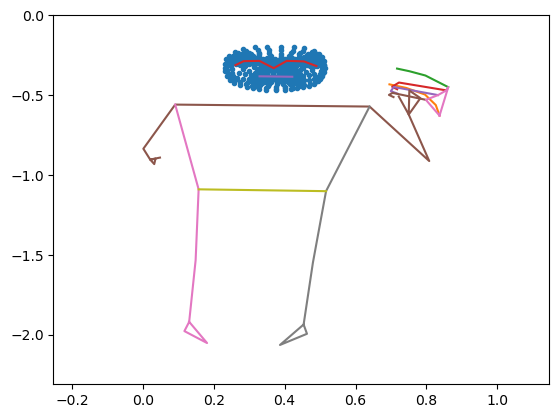

In [111]:
def animation_frame(f):
    frame = sign[sign.frame==f]
    left = frame[frame.type=='left_hand']
    right = frame[frame.type=='right_hand']
    pose = frame[frame.type=='pose']
    face = frame[frame.type=='face'][['x', 'y']].values
    lx, ly = get_hand_points(left)
    rx, ry = get_hand_points(right)
    px, py = get_pose_points(pose)
    ax.clear()
    ax.plot(face[:,0], face[:,1], '.')
    for i in range(len(lx)):
        ax.plot(lx[i], ly[i])
    for i in range(len(rx)):
        ax.plot(rx[i], ry[i])
    for i in range(len(px)):
        ax.plot(px[i], py[i])
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
        
print(f"The sign being shown here is: {train[train.path==f'{path_to_sign}'].sign.values[0]}")

## These values set the limits on the graph to stabilize the video
xmin = sign.x.min() - 0.2
xmax = sign.x.max() + 0.2
ymin = sign.y.min() - 0.2
ymax = sign.y.max() + 0.2

fig, ax = plt.subplots()
l, = ax.plot([], [])
animation = FuncAnimation(fig, func=animation_frame, frames=sign.frame.unique())

HTML(animation.to_html5_video())

The sign being shown here is: face


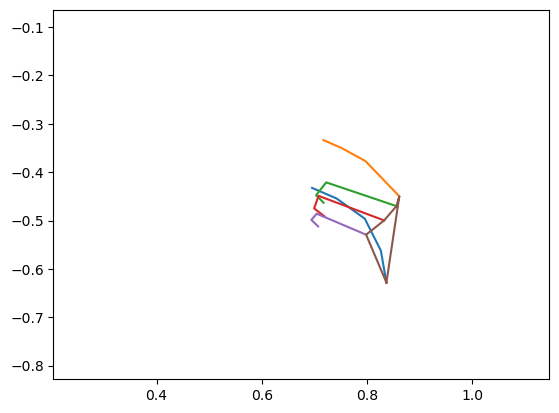

In [112]:
sign = sign[sign.type=='left_hand'].dropna()
def animation_frame(f):
    frame = sign[sign.frame==f]
    left = frame[frame.type=='left_hand']
    lx, ly = get_hand_points(left)
    ax.clear()
    for i in range(len(lx)):
        ax.plot(lx[i], ly[i])
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

        
print(f"The sign being shown here is: {train[train.path==f'{path_to_sign}'].sign.values[0]}")

## These values set the limits on the graph to stabilize the video
xmin = sign.x.min() - 0.2
xmax = sign.x.max() + 0.2
ymin = sign.y.min() - 0.2
ymax = sign.y.max() + 0.2

fig, ax = plt.subplots()
l, = ax.plot([], [])
animation = FuncAnimation(fig, func=animation_frame, frames=sign.frame.unique())

HTML(animation.to_html5_video())

In [113]:
print('The End')

The End
